# Image Normalisation

## Setup

In [1]:
import cv2                     
import numpy as np            
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm 
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE = '/content/drive/MyDrive/Melanoma Project'
TRAIN_DIR = BASE + "/train"        
TEST_DIR  = BASE + "/test"
OUT_TRAIN = BASE + "/proc_train"   
OUT_TEST  = BASE + "/proc_test"
Path(OUT_TRAIN).mkdir(exist_ok=True)
Path(OUT_TEST).mkdir(exist_ok=True)

train_df = pd.read_csv(BASE + '/train_labels.csv')
test_df  = pd.read_csv(BASE + '/test_labels.csv')

print(train_df.shape, test_df.shape)   
train_df.head()

(6864, 8) (1988, 8)


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
1,ISIC_0074542,IP_4698288,male,25.0,lower extremity,unknown,benign,0
2,ISIC_0076545,IP_9802602,male,55.0,upper extremity,unknown,benign,0
3,ISIC_0082348,IP_7684360,male,55.0,torso,unknown,benign,0
4,ISIC_0085172,IP_1705144,female,50.0,lower extremity,unknown,benign,0


In [4]:
def add_image_path(df, img_dir, ext=".jpg"):
    """Add an 'image_path' column = full path string to each row's image."""
    df = df.copy()                         # No mutation of the original in place
    df["image_path"] = df["image_name"].apply(lambda n: Path(str(img_dir + f"/{n}{ext}")))
    return df

In [5]:
train_df = add_image_path(train_df, TRAIN_DIR)
test_df  = add_image_path(test_df,  TEST_DIR)

train_df[["image_name", "target", "image_path"]].head()

,image_name,target,image_path
0,ISIC_0015719,0,/content/drive/MyDrive/Melanoma Project/train/...
1,ISIC_0074542,0,/content/drive/MyDrive/Melanoma Project/train/...
2,ISIC_0076545,0,/content/drive/MyDrive/Melanoma Project/train/...
3,ISIC_0082348,0,/content/drive/MyDrive/Melanoma Project/train/...
4,ISIC_0085172,0,/content/drive/MyDrive/Melanoma Project/train/...


## Sanity Check

In [6]:
RANDOM_STATE = 42
SAMPLE_N     = 50

sample = train_df.sample(n=SAMPLE_N, random_state=RANDOM_STATE)

shapes_train = []
for path in tqdm(sample['image_path'], total=len(sample)):
    with Image.open(path) as im:            # 'with' -> file closes after each read
        shapes_train.append(im.size)        # PIL .size == (width, height)

shapes_train = pd.DataFrame(shapes_train, columns=['W', 'H'])     # was ['H','W'] — .size is (W,H)
shapes_train['Size'] = '[' + shapes_train['W'].astype(str) + ', ' + shapes_train['H'].astype(str) + ']'

  0%|          | 0/50 [00:00<?, ?it/s]

In [7]:
shapes_train

,W,H,Size
0,512,512,"[512, 512]"
1,512,512,"[512, 512]"
2,512,512,"[512, 512]"
3,512,512,"[512, 512]"
4,512,512,"[512, 512]"
5,512,512,"[512, 512]"
6,512,512,"[512, 512]"
7,512,512,"[512, 512]"
8,512,512,"[512, 512]"
9,512,512,"[512, 512]"


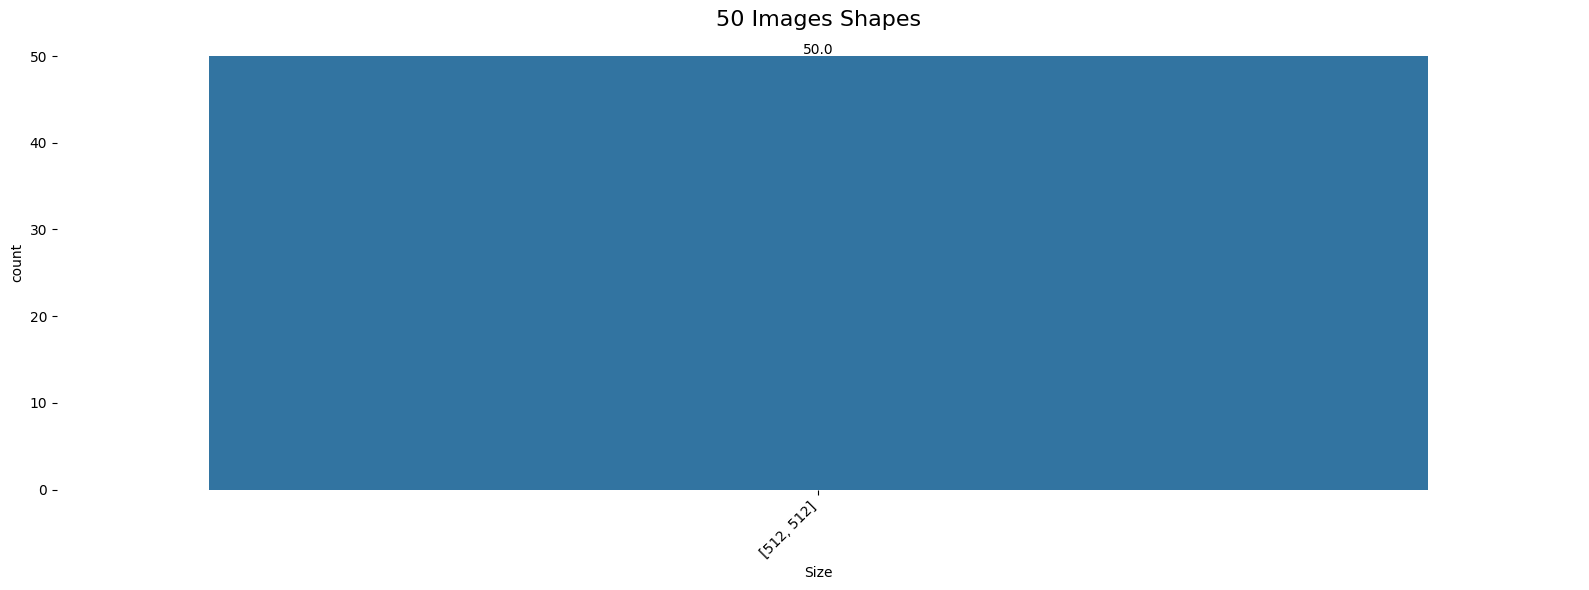

In [8]:
plt.figure(figsize=(16, 6))

order = shapes_train['Size'].value_counts().index      # bars sorted most -> least common
a = sns.countplot(data=shapes_train, x='Size', order=order)
#   seaborn >=0.12 requires x= (or y=) + data=; passing a bare Series no longer works

for p in a.patches:                                    # your annotation loop, unchanged
    a.annotate(format(p.get_height(), ','),
               (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='center',
               xytext=(0, 4), textcoords='offset points')
a
plt.xticks(rotation=45, ha='right')                    # stop long "[3000, 4000]" labels overlapping
plt.title(f'{len(shapes_train)} Images Shapes', fontsize=16)
sns.despine(left=True, bottom=True)
plt.tight_layout()                                     # so rotated labels aren't clipped
plt.show()

## Normalise

### Small helpers

In [9]:
def to_rgb(path):
    """Read an image file as an RGB uint8 array of shape (H, W, 3).

    cv2.imread(str(path))  -> loads as BGR, or returns None (no error!) if the
                              path is wrong, so we check.
    cv2.cvtColor(..., COLOR_BGR2RGB) -> swap Blue and Red so colours look right
                              in matplotlib and stay consistent downstream.
    """
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [10]:
def panel(ax, im, title):
    """Show one image on a matplotlib axis; auto-handle gray vs colour."""
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

### Hair removal (DullRazor)

Parameters: 
kernel_size: black-hat probe size (px). Must exceed hair width (13–17: Too small → misses thick hair. Too big → eats lesion detail)

thresh: black-hat brightness above which a pixel = hair (8–15: Lower → catches faint hair + more noise)

inpaint_radius: 
neighbourhood radius for the fill (1: Larger → smoother but blurrier fill)

In [11]:
def remove_hair(rgb, kernel_size=17, thresh=10, inpaint_radius=1, return_steps=False):
    """DullRazor hair removal.

    METHODS:

    1. cv2.cvtColor(rgb, COLOR_RGB2GRAY)
         Hair contrast is a brightness thing; colour is not needed here.

    2. cv2.getStructuringElement(MORPH_ELLIPSE, (k, k))
         Builds the 'probe' shape that morphology slides over the image.
         ELLIPSE ≈ circular, so it catches hair at any angle.
         k MUST be a little larger than a hair is wide.

    3. cv2.morphologyEx(gray, MORPH_BLACKHAT, kernel)
         black-hat = closing(gray) - gray.
         Closing erases anything thinner than the kernel (the hairs), giving a
         hair-free version; subtracting the original brings back ONLY what was
         erased -> the hairs, as bright streaks on a black field.

    4. cv2.threshold(blackhat, thresh, 255, THRESH_BINARY)
         Any streak brighter than `thresh` becomes 255 (white = hair);
         everything else 0. Returns (used_value, mask); we keep the mask.

    5. cv2.dilate(mask, small_kernel)
         Grows the mask by ~1px so the soft EDGES of each hair are covered too,
         otherwise a faint outline is left behind after inpainting.

    6. cv2.inpaint(rgb, mask, inpaint_radius, INPAINT_TELEA)
         Treats masked pixels as 'missing' and reconstructs them from a
         neighbourhood of radius `inpaint_radius`. TELEA = Fast Marching Method.
    """
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, thresh, 255, cv2.THRESH_BINARY)
    mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    clean = cv2.inpaint(rgb, mask, inpaint_radius, cv2.INPAINT_TELEA)

    if return_steps:
        return clean, {"gray": gray, "blackhat": blackhat, "mask": mask}
    return clean


def hair_fraction(rgb, kernel_size=17, thresh=10):
    """Fraction of pixels flagged as hair — a cheap 'hairiness' score for EDA
    and for picking example images."""
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    bh = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, m = cv2.threshold(bh, thresh, 255, cv2.THRESH_BINARY)
    return float((m > 0).mean())

### Corner handeling

### Lesion segmentation and centring

In [12]:
def segment_lesion(rgb, min_frac=0.003, max_frac=0.9, clean_kernel=7, blur_kernel=9):
    """Lesion blob -> dict(bbox, centroid, area_frac, mask) or None. No FOV restriction.
    Return dict(bbox, centroid, area_frac, mask) for the lesion, or None.

    METHODS:

    1. cv2.GaussianBlur(gray, (b, b), 0)
         smooth away texture/noise so Otsu isn't fooled. 0 = derive sigma from
         the kernel size.

    2. cv2.threshold(fov_values, 0, 255, THRESH_BINARY + THRESH_OTSU)
         Otsu picks the split point automatically from the histogram of ONLY
         the FOV pixels (passed as a 1-column array). We then apply it as
         (blur < T) & fov  ->  dark AND inside the photo = candidate lesion.

    3. cv2.morphologyEx(mask, MORPH_OPEN) then MORPH_CLOSE
         OPEN removes small white specks; CLOSE fills small holes in the blob.

    4. cv2.connectedComponentsWithStats(mask)
         area + bbox + centroid for every blob. We reject blobs that are too
         small/large, then keep the one maximising  frac * (1 - 0.5*dist),
         i.e. big and near the centre."""
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    H, W = gray.shape
    blur = cv2.GaussianBlur(gray, (blur_kernel, blur_kernel), 0)

    T, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)  # dark -> white

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (clean_kernel, clean_kernel))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)

    n, labels, stats, cents = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n <= 1:
        return None
    cx, cy = W / 2, H / 2
    diag = np.hypot(cx, cy)
    best, best_score = None, -1.0
    for i in range(1, n):
        frac = stats[i, cv2.CC_STAT_AREA] / (H * W)
        if frac < min_frac or frac > max_frac:
            continue
        dist = np.hypot(cents[i][0] - cx, cents[i][1] - cy) / diag
        score = frac * (1.0 - 0.5 * dist)
        if score > best_score:
            best, best_score = i, score
    if best is None:
        return None
    x, y, w, h = (stats[best, cv2.CC_STAT_LEFT], stats[best, cv2.CC_STAT_TOP],
                  stats[best, cv2.CC_STAT_WIDTH], stats[best, cv2.CC_STAT_HEIGHT])
    return {"bbox": (int(x), int(y), int(x + w), int(y + h)),
            "centroid": (float(cents[best][0]), float(cents[best][1])),
            "area_frac": float(stats[best, cv2.CC_STAT_AREA] / (H * W)),
            "mask": (labels == best)}



def centered_square_crop(rgb, centroid, box_side, out_size=256):
    """Cut a square of side `box_side` centred on `centroid`; if it runs off an
    edge, SLIDE it back in (stays square) instead of clipping lopsidedly.
    Then resize to out_size with INTER_AREA (best for shrinking)."""
    H, W = rgb.shape[:2]
    box_side = int(round(min(box_side, H, W)))
    cx, cy = centroid
    x0 = int(round(cx - box_side / 2)); y0 = int(round(cy - box_side / 2))
    x1, y1 = x0 + box_side, y0 + box_side
    if x0 < 0:  x1 -= x0; x0 = 0
    if y0 < 0:  y1 -= y0; y0 = 0
    if x1 > W:  x0 -= (x1 - W); x1 = W
    if y1 > H:  y0 -= (y1 - H); y1 = H
    crop = rgb[max(0, y0):y1, max(0, x0):x1]
    crop = cv2.resize(crop, (out_size, out_size), interpolation=cv2.INTER_AREA)
    return crop, (int(x0), int(y0), int(x1), int(y1)) 

### The full preprocess() (chains 2–5)

In [22]:
def preprocess(path, out_size=256, hair_kernel=17, margin=0.25,
               route="full", rgb=None, return_steps=False):      # + rgb=None
    if rgb is None:                                              # + these two lines
        rgb = to_rgb(path)                                       #

    if route == "raw":                                  # anomaly images: keep raw, just resize
        final = cv2.resize(rgb, (out_size, out_size), interpolation=cv2.INTER_AREA)
        info = {"status": "raw_kept", "lesion_frac": np.nan, "route": route}
        return (final, info, {"raw": rgb, "final": final}) if return_steps else (final, info)

    steps = {"raw": rgb}

    if route == "no_hair":
        nohair = rgb
        g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        steps.update(gray=g, blackhat=np.zeros_like(g),
                     hair_mask=np.zeros_like(g), hair_removed=nohair)
    else:
        nohair, hs = remove_hair(rgb, kernel_size=hair_kernel, return_steps=True)
        steps.update(gray=hs["gray"], blackhat=hs["blackhat"],
                     hair_mask=hs["mask"], hair_removed=nohair)

    seg = segment_lesion(nohair)
    H, W = nohair.shape[:2]
    overlay = nohair.copy()
    if seg is None:
        status = "seg_fail"
        centroid, box_side, lesion_frac = (W / 2, H / 2), min(H, W), np.nan
        steps["lesion_mask"] = np.zeros((H, W), np.uint8)
    else:
        status = "ok"
        x0, y0, x1, y1 = seg["bbox"]
        centroid = seg["centroid"]
        box_side = max(x1 - x0, y1 - y0) * (1 + 2 * margin)
        lesion_frac = seg["area_frac"]
        steps["lesion_mask"] = (seg["mask"].astype(np.uint8) * 255)
        cv2.rectangle(overlay, (x0, y0), (x1, y1), (0, 255, 0), 2)
        cv2.circle(overlay, (int(centroid[0]), int(centroid[1])), 4, (255, 0, 0), -1)
    steps["lesion_overlay"] = overlay

    final, win = centered_square_crop(nohair, centroid, box_side, out_size=out_size)
    steps["final"] = final
    info = {"status": status, "lesion_frac": lesion_frac, "crop_win": win, "route": route}
    return (final, info, steps) if return_steps else (final, info)

### Visual walkthrough (raw → processed, step by step)

In [14]:
probe = train_df.sample(100, random_state=1)
rows = []
for name, p in tqdm(zip(probe["image_name"], probe["image_path"]), total=len(probe)):
    im = to_rgb(p)
    rows.append({"image_name": name, "hair": hair_fraction(im)})
scores = pd.DataFrame(rows)

print(scores.sort_values("hair", ascending=False).head())

  0%|          | 0/100 [00:00<?, ?it/s]

      image_name      hair
92  ISIC_0261693  0.657993
7   ISIC_5666345  0.439754
89  ISIC_9271800  0.311779
58  ISIC_1739748  0.266212
46  ISIC_1020208  0.264900


In [15]:
scores

,image_name,hair
0,ISIC_3269939,0.022129
1,ISIC_4788878,0.002712
2,ISIC_7375608,0.104881
3,ISIC_8106576,0.131813
4,ISIC_3508550,0.022438
...,...,...
95,ISIC_2523171,0.031311
96,ISIC_7751774,0.061981
97,ISIC_2657913,0.034889
98,ISIC_9042958,0.253204


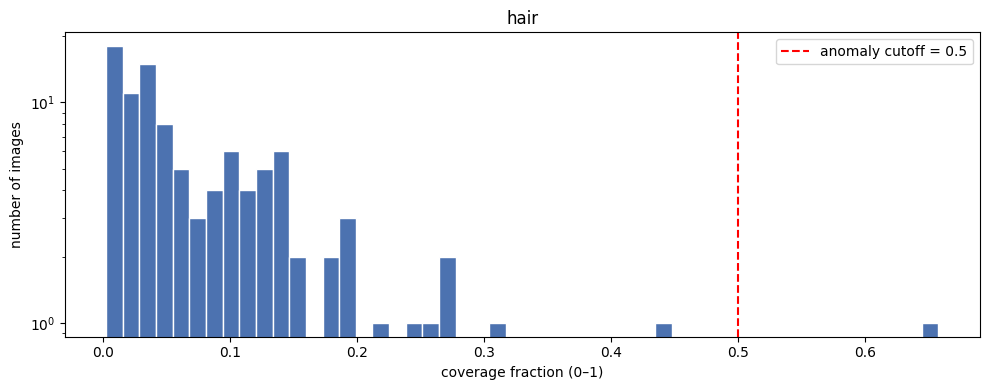

,hair
count,100.000000
mean,0.086886
std,0.097293
min,0.002640
25%,0.022361
50%,0.051708
75%,0.122760
max,0.657993


In [16]:
metric = "hair"

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores[metric], bins=50, color="#4C72B0", edgecolor="white")
ax.axvline(0.5, color="red", ls="--", label="anomaly cutoff = 0.5")   # your threshold
ax.set_title(metric)
ax.set_xlabel("coverage fraction (0–1)")
ax.set_ylabel("number of images")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

scores[[metric]].describe()

In [17]:
THRESH      = 0.5
metric_cols = ["hair"]                     # list, even with one column

# 1. flag: anomaly if ANY metric covers > 50% of the image
scores["is_anomaly"] = (scores[metric_cols] > THRESH).any(axis=1)

# 2. route
scores["route"] = np.where(scores["is_anomaly"], "raw", "full")

print(scores["is_anomaly"].value_counts())
print(scores.loc[scores["is_anomaly"], ["image_name"] + metric_cols])

# 3. keep originals for the report
scores[[c + "_orig" for c in metric_cols]] = scores[metric_cols]

# 4. zero the anomalies' scores
scores.loc[scores["is_anomaly"], metric_cols] = 0.0

scores.head()

is_anomaly
False    99
True      1
Name: count, dtype: int64
      image_name      hair
92  ISIC_0261693  0.657993


,image_name,hair,is_anomaly,route,hair_orig
0,ISIC_3269939,0.022129,False,full,0.022129
1,ISIC_4788878,0.002712,False,full,0.002712
2,ISIC_7375608,0.104881,False,full,0.104881
3,ISIC_8106576,0.131813,False,full,0.131813
4,ISIC_3508550,0.022438,False,full,0.022438


In [18]:
scores.sort_values("hair", ascending=False)

,image_name,hair,is_anomaly,route,hair_orig
7,ISIC_5666345,0.439754,False,full,0.439754
89,ISIC_9271800,0.311779,False,full,0.311779
58,ISIC_1739748,0.266212,False,full,0.266212
46,ISIC_1020208,0.264900,False,full,0.264900
98,ISIC_9042958,0.253204,False,full,0.253204
...,...,...,...,...,...
87,ISIC_3893659,0.006401,False,full,0.006401
9,ISIC_3460125,0.004250,False,full,0.004250
1,ISIC_4788878,0.002712,False,full,0.002712
73,ISIC_6033222,0.002640,False,full,0.002640


In [19]:
hairy_path = train_df.set_index("image_name").loc[
    scores.sort_values("hair", ascending=False).iloc[0]["image_name"], "image_path"]

In [20]:
CAPTIONS = [
    ("raw",            "1. RAW input (512×512)"),
    ("gray",           "2. Grayscale — brightness only"),
    ("blackhat",       "3. Black-hat — thin dark hair lights up"),
    ("mask",           "4. Hair mask — threshold of panel 3"),
    ("hair_removed",   "5. Hair inpainted away (cv2.inpaint)"),
    ("lesion_mask",    "6. Lesion mask — Otsu + morphology"),
    ("lesion_overlay", "7. Lesion blob: green bbox, red centroid"),
    ("final",          "8. Centred on centroid + resized"),
]

def show_pipeline(path, **kw):
    final, info, steps = preprocess(path, return_steps=True, **kw)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))          # 8 panels now, not 10
    for ax, (key, title) in zip(axes.ravel(), CAPTIONS):
        im = steps.get(key)                                  # 'raw' route only has raw+final
        if im is None:
            ax.set_title(title, fontsize=9); ax.axis("off")
        else:
            panel(ax, im, title)
    fig.suptitle(f"{Path(path).name}   status={info['status']}   "
                 f"lesion_frac={info['lesion_frac']}", fontsize=12)
    plt.tight_layout(); plt.show()

path_by_name = train_df.set_index("image_name")["image_path"]   # lookup: name -> path

col = "hair_orig" if "hair_orig" in scores.columns else "hair"   # anomalies were zeroed in 'hair'

ISIC_1739748 /content/drive/MyDrive/Melanoma Project/train/ISIC_1739748.jpg


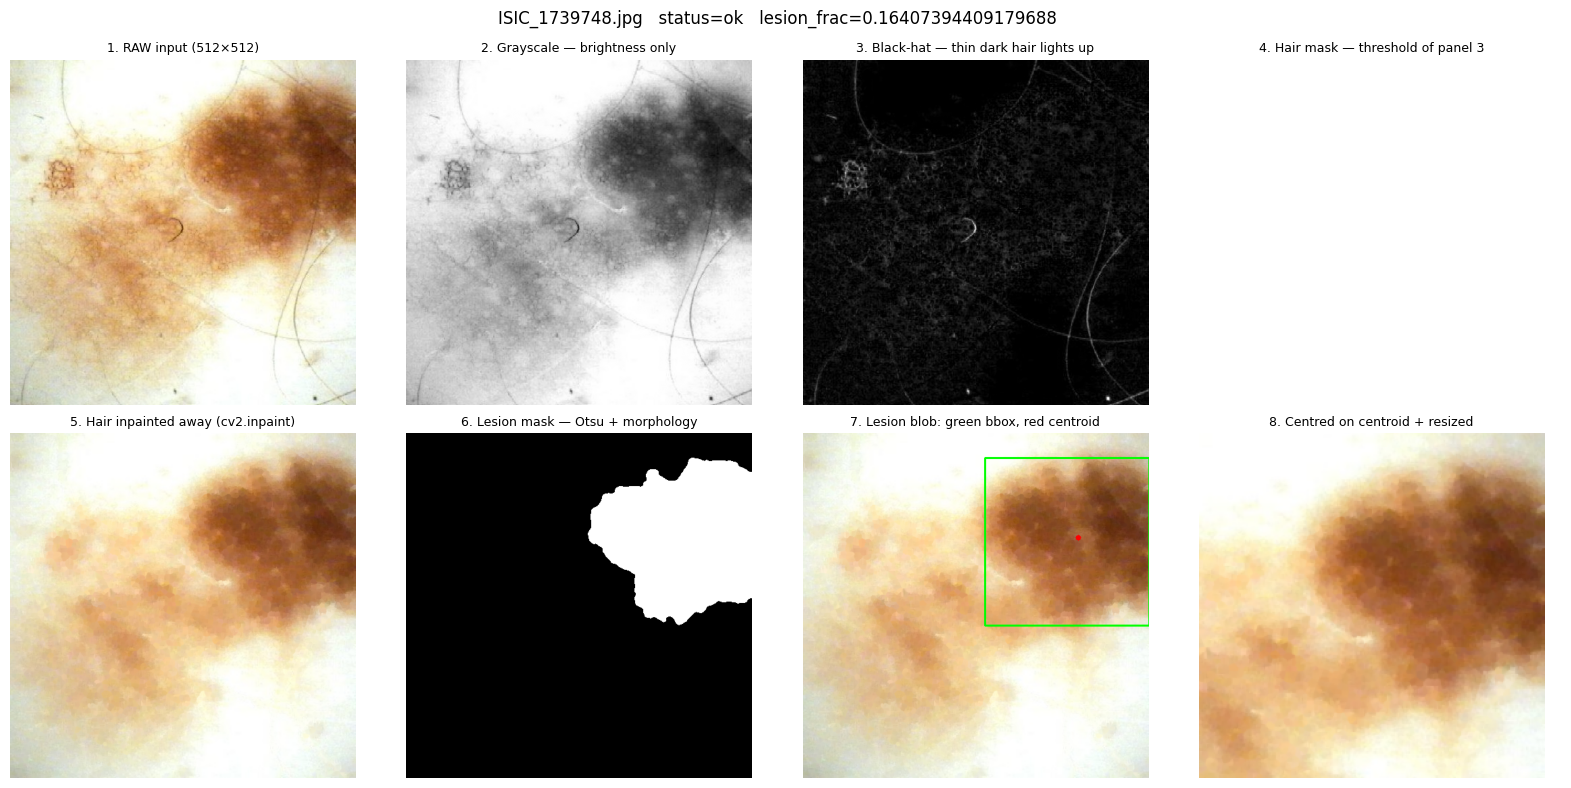

In [21]:
hairy_name = scores.sort_values(col, ascending=False).iloc[3]["image_name"]
hairy_path = path_by_name[hairy_name]

print(hairy_name, hairy_path)
show_pipeline(hairy_path)

### Batch run

In [24]:
OUT_SIZE       = 256
OUTLIER_THRESH = 0.5      # hair coverage above this -> keep the RAW image, don't crop

def run_batch(df, out_dir, out_size=OUT_SIZE, outlier_thresh=OUTLIER_THRESH):
    """Process every row of df, save to out_dir/<image_name>.jpg, return a manifest
    merged back onto df on image_name (order + correspondence preserved)."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    recs = []
    for name, path in tqdm(zip(df["image_name"], df["image_path"]), total=len(df)):
        rec = {"image_name": name, "status": "error", "route": None,
               "hair_frac": np.nan, "lesion_frac": np.nan, "proc_path": None}
        try:
            rgb = to_rgb(path)                                   # read once
            hf  = hair_fraction(rgb)                             # outlier score
            route = "raw" if hf > outlier_thresh else "full"     # <-- outlier removal
            final, info = preprocess(path, rgb=rgb, route=route, out_size=out_size)

            dst = out_dir / f"{name}.jpg"
            cv2.imwrite(str(dst), cv2.cvtColor(final, cv2.COLOR_RGB2BGR))   # RGB -> BGR to save
            rec.update(status=info["status"], route=route, hair_frac=hf,
                       lesion_frac=info["lesion_frac"], proc_path=str(dst))
        except Exception as e:
            rec["status"] = f"error:{type(e).__name__}"
        recs.append(rec)

    manifest = pd.DataFrame(recs)
    out = df.merge(manifest, on="image_name", how="left", validate="one_to_one")
    assert len(out) == len(df), "row count changed — correspondence broken"
    return out

In [25]:
train_proc = run_batch(train_df, OUT_TRAIN)
test_proc  = run_batch(test_df,  OUT_TEST)

for split, m in [("TRAIN", train_proc), ("TEST", test_proc)]:
    print(f"\n=== {split} ===")
    print(m["route"].value_counts(dropna=False))
    print(m["status"].value_counts(dropna=False))

train_proc.to_csv(BASE + "/train_processed_manifest.csv", index=False)
test_proc.to_csv(BASE + "/test_processed_manifest.csv", index=False)

  0%|          | 0/6864 [00:00<?, ?it/s]

  0%|          | 0/1988 [00:00<?, ?it/s]


=== TRAIN ===
route
full    6834
raw       30
Name: count, dtype: int64
status
ok          6833
raw_kept      30
seg_fail       1
Name: count, dtype: int64

=== TEST ===
route
full    1981
raw        7
Name: count, dtype: int64
status
ok          1981
raw_kept       7
Name: count, dtype: int64


In [26]:
for split, m in [("train", train_proc), ("test", test_proc)]:
    out = m.loc[m["route"] == "raw", ["image_name", "hair_frac"]].sort_values(
        "hair_frac", ascending=False)
    print(f"{split}: {len(out)} outliers (hair coverage > {OUTLIER_THRESH}) kept as raw resized images")
    display(out)

train: 30 outliers (hair coverage > 0.5) kept as raw resized images


,image_name,hair_frac
5088,ISIC_7404470,0.797291
119,ISIC_0261693,0.657993
5617,ISIC_8158542,0.656128
4857,ISIC_7059744,0.656010
1677,ISIC_2536936,0.652046
1956,ISIC_2949131,0.644180
914,ISIC_1453146,0.640129
1005,ISIC_1572957,0.636589
6568,ISIC_9548034,0.634007
1921,ISIC_2907732,0.633247


test: 7 outliers (hair coverage > 0.5) kept as raw resized images


,image_name,hair_frac
793,ISIC_4048509,0.594940
1560,ISIC_7907808,0.584911
1685,ISIC_8523496,0.569256
754,ISIC_3866641,0.554920
483,ISIC_2423162,0.553959
1932,ISIC_9733758,0.534981
1217,ISIC_6204305,0.503288


## Acknowledgements

 Image-processing methods used in this project. Several techniques below were new to our team; we applied them from public sources and cite them here.

Hair removal — DullRazor. The algorithm is DullRazor (Lee, Ng, Gallagher, Coldman & McLean, 1997, "DullRazor: A software approach to hair removal from images", Computers in Biology and Medicine 27(6)). Our implementation — grayscale → morphological black-hat → binary threshold → cv2.inpaint(..., cv2.INPAINT_TELEA) — is adapted from Vatsal Parsaniya, "Melanoma Hair Remove", Kaggle (kaggle.com/code/vatsalparsaniya/melanoma-hair-remove). We changed his cv2.MORPH_CROSS 17×17 kernel to cv2.MORPH_ELLIPSE (better for diagonal hair) and added a 3×3 dilation of the mask before inpainting to remove faint hair edges. The inpainting method itself is Telea (2004), "An Image Inpainting Technique Based on the Fast Marching Method", as implemented in OpenCV.

EDA framing and image sanity-check plots (resolution distribution, sample grids) follow Andrada Olteanu, "SIIM Melanoma Competition: EDA + Augmentations", Kaggle (kaggle.com/code/andradaolteanu/siim-melanoma-competition-eda-augmentations).

Leakage-free, patient-level splitting follows the discussion in Kaggle thread #165582 (kaggle.com/c/siim-isic-melanoma-classification/discussion/165582) and the project brief.

Automatic thresholding uses Otsu's method (Otsu, 1979), via cv2.threshold(..., cv2.THRESH_OTSU).

Field-of-view / vignette detection (largest non-black connected component + morphological hole-filling) and lesion segmentation (Gaussian blur → Otsu on the field-of-view → morphological open/close → largest central component) are standard OpenCV recipes from the OpenCV documentation (Morphological Transformations, Image Thresholding, Contours / Connected Components, Image Inpainting); they are not taken from a specific notebook.

Written by our team: the field-of-view masking function, the median-skin fill, the size-×-centrality blob-scoring rule, the centroid-centred square-crop-with-slide logic, and the correspondence-safe batch/manifest code.